# Linear Regression

## Setup

### Load in Libraries

In [1]:
import pandas as pd
import ucimlrepo
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Retrieve Dataset

In [2]:
# use the ucimlrepo package to load the dataset Metro Interstate Traffic Volume
dataset = ucimlrepo.fetch_ucirepo(name="Metro Interstate Traffic Volume")
df = dataset.data.original

In [3]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## Data Processing

In [4]:
# find any missing/null values
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [5]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [6]:
# determine the data type for each column
df.dtypes

holiday                    str
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main               str
weather_description        str
date_time                  str
traffic_volume           int64
dtype: object

### Continuous Variables

In [7]:
def getOutliers(df, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # Calculate the IQR (Interquartile Range)
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers

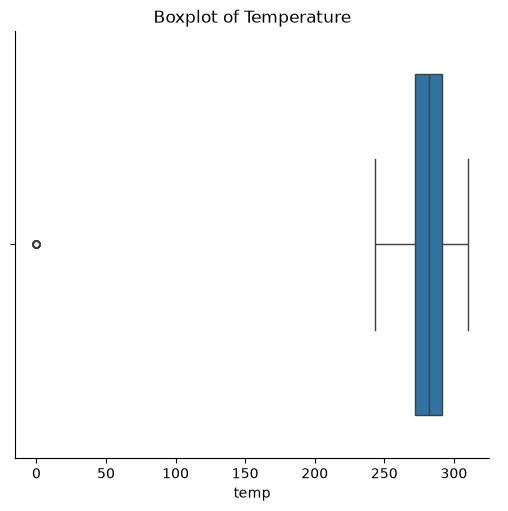

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11898,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 03:00:00,361
11899,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 04:00:00,734
11900,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 05:00:00,2557
11901,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 06:00:00,5150
11946,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 03:00:00,291
11947,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 04:00:00,284
11948,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 05:00:00,434
11949,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 06:00:00,739
11950,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 07:00:00,962
11951,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 08:00:00,1670


In [8]:
# boxplot of each numerical column
sns.catplot(data = df, x = 'temp',kind = 'box')
plt.title('Boxplot of Temperature')
plt.show()
getOutliers(df, 'temp')

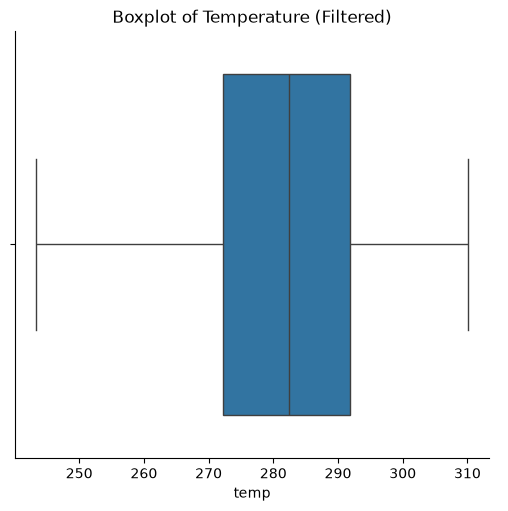

In [9]:
# Keep only the rows where the temperature is greater than 0,
# since a temperature of 0 kelvin is physically impossible and likely indicates a data entry error.
df = df[df['temp'] > 0]
sns.catplot(df, x = 'temp',kind = 'box')
plt.title('Boxplot of Temperature (Filtered)')
plt.show()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
24872,NaN,302.11,9831.30,0.0,75,Rain,very heavy rain,2016-07-11 17:00:00,5535
8247,NaN,289.10,55.63,0.0,68,Rain,very heavy rain,2013-08-07 02:00:00,315
7179,NaN,295.82,44.45,0.0,76,Rain,very heavy rain,2013-06-24 11:00:00,4802
25779,NaN,297.71,31.75,0.0,0,Rain,very heavy rain,2016-08-16 17:00:00,4913
10806,NaN,264.50,28.70,0.0,64,Rain,very heavy rain,2013-12-19 23:00:00,1190
...,...,...,...,...,...,...,...,...,...
6718,NaN,285.40,0.25,0.0,92,Rain,light rain,2013-06-06 05:00:00,2749
6709,NaN,285.65,0.25,0.0,92,Mist,mist,2013-06-06 00:00:00,655
6708,NaN,285.65,0.25,0.0,92,Rain,light rain,2013-06-06 00:00:00,655
6705,NaN,286.26,0.25,0.0,92,Drizzle,light intensity drizzle,2013-06-05 22:00:00,1922


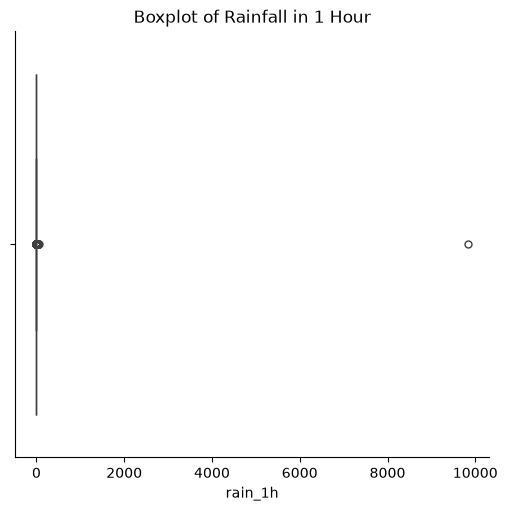

In [10]:
sns.catplot(data = df, x = 'rain_1h',kind = 'box')
plt.title('Boxplot of Rainfall in 1 Hour')
getOutliers(df, 'rain_1h').sort_values(by='rain_1h', ascending=False)

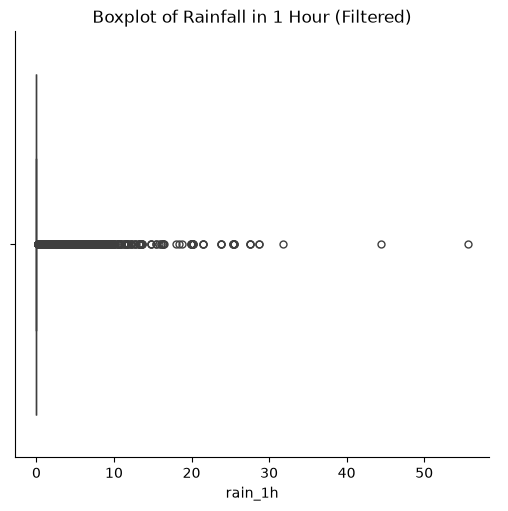

In [11]:
# Keep only the rows where the rainfall in 1 hour is less than 9831.30,
# since a rainfall of 9831.30 mm in 1 hour is physically impossible and likely indicates a data entry error.
df = df[df['rain_1h'] < 9831.30]

sns.catplot(data = df, x = 'rain_1h',kind = 'box')
plt.title('Boxplot of Rainfall in 1 Hour (Filtered)')
plt.show()

Text(0.5, 1.0, 'Boxplot of Traffic Volume')

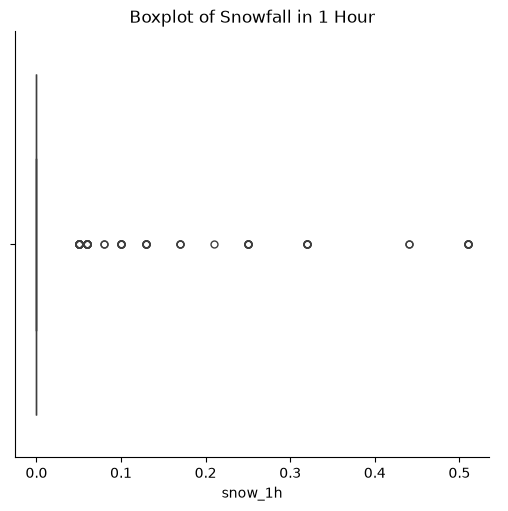

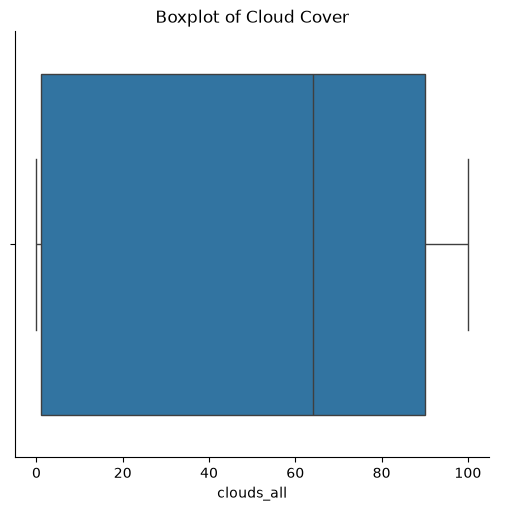

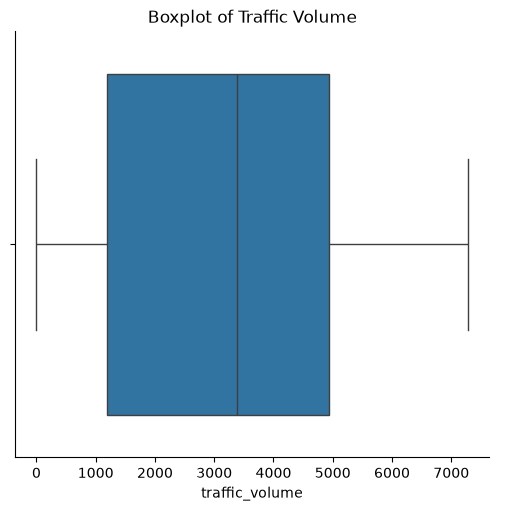

In [12]:

sns.catplot(data = df, x = 'snow_1h',kind = 'box')
plt.title('Boxplot of Snowfall in 1 Hour')

sns.catplot(df, x = 'clouds_all',kind = 'box')
plt.title('Boxplot of Cloud Cover')

sns.catplot(data = df, x = 'traffic_volume',kind = 'box')
plt.title('Boxplot of Traffic Volume')

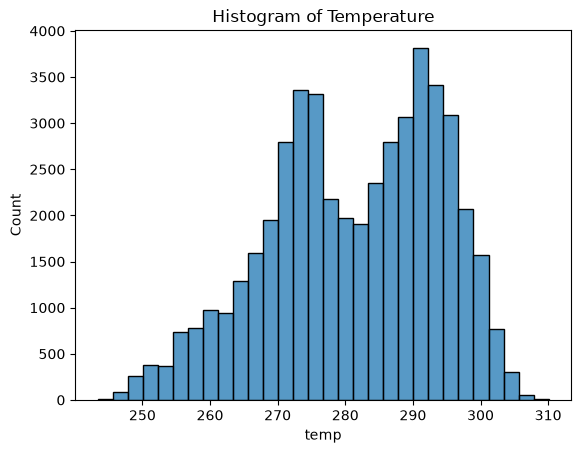

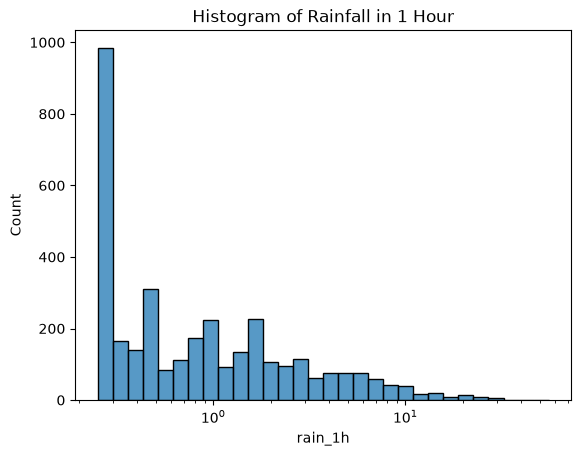

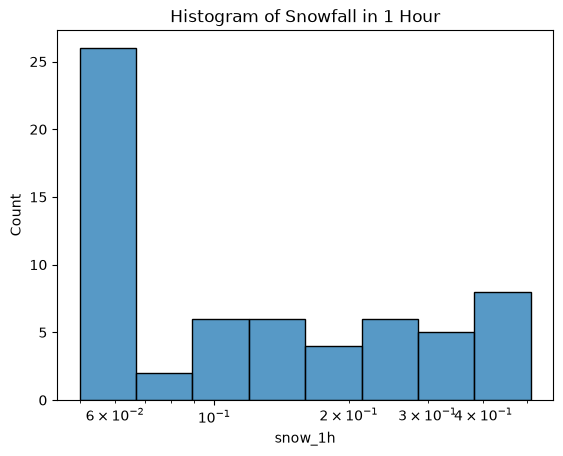

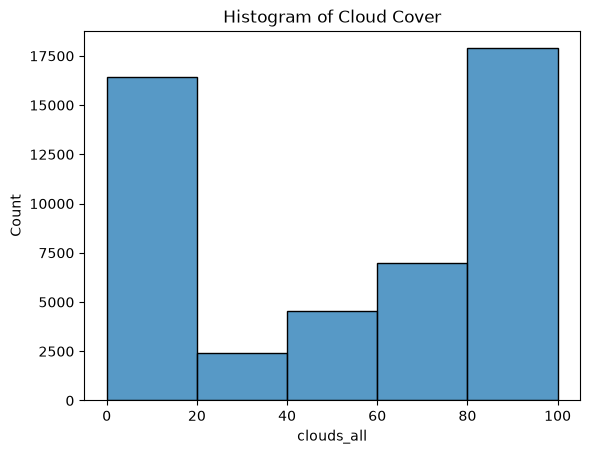

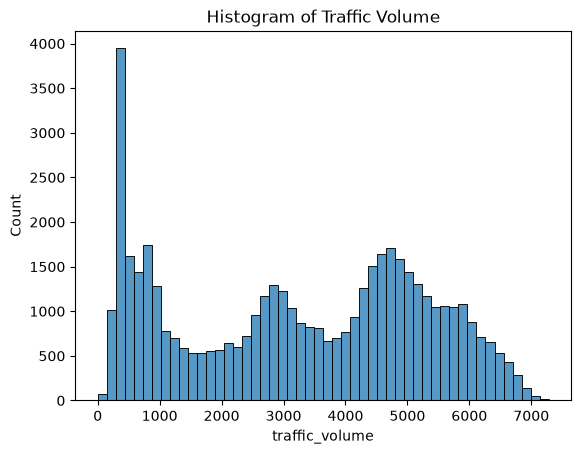

In [13]:
# plot histograms of continuous variables
sns.histplot(data=df, x='temp', bins=30)
plt.title('Histogram of Temperature')
plt.show()

sns.histplot(data=df, x='rain_1h', bins=30, log_scale=True)
plt.title('Histogram of Rainfall in 1 Hour')
plt.show()

sns.histplot(data=df, x='snow_1h', bins=8, log_scale=True)
plt.title('Histogram of Snowfall in 1 Hour')
plt.show()

sns.histplot(data=df, x='clouds_all', bins=5)
plt.title('Histogram of Cloud Cover')
plt.show()

sns.histplot(data=df, x='traffic_volume', bins=50)
plt.title('Histogram of Traffic Volume')
plt.show()

### Categorical Variables

In [14]:
df['holiday'].value_counts()

holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

In [15]:
df['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13381
Mist             5950
Rain             5671
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [16]:
df['weather_description'].value_counts()

weather_description
sky is clear                           11655
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
light rain                              3372
few clouds                              1956
light snow                              1946
Sky is Clear                            1726
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1100
fog                                      912
proximity thunderstorm                   673
drizzle                                  651
heavy snow                               616
heavy intensity rain                     467
snow                                     293
proximity shower rain                    136
thunderstorm                             125
heavy intensity drizzle                   64
thunderstorm with heavy rain       

In [17]:
df['date_time'].value_counts()

date_time
2013-04-18 22:00:00    6
2013-05-19 10:00:00    6
2012-10-25 15:00:00    5
2012-10-26 04:00:00    5
2012-11-11 04:00:00    5
                      ..
2018-09-30 19:00:00    1
2018-09-30 20:00:00    1
2018-09-30 21:00:00    1
2018-09-30 22:00:00    1
2018-09-30 23:00:00    1
Name: count, Length: 40564, dtype: int64

In [18]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['year'] = df['date_time'].dt.year 
df['month'] = df['date_time'].dt.month
df['dayOfWeek'] = df['date_time'].dt.dayofweek + 1 # 1 = Monday, 7 = Sunday
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour + 1
df['isWeekend'] = df['date_time'].dt.dayofweek >= 6

In [19]:
df[['year', 'month', 'day', 'dayOfWeek', 'hour', 'isWeekend']].aggregate(['min', 'max'])

,year,month,day,dayOfWeek,hour,isWeekend
min,2012,1,1,1,1,False
max,2018,12,31,7,24,True


In [20]:
# pull each row that has a holiday and display the date_time, holiday, and traffic_volume columns and print to a csv file
df[df['holiday'].notna()][['month', 'day', 'year', 'holiday']].drop_duplicates()

,month,day,year,holiday
126,10,8,2012,Columbus Day
1123,11,12,2012,Veterans Day
1370,11,22,2012,Thanksgiving Day
2360,12,25,2012,Christmas Day
2559,1,1,2013,New Years Day
3697,2,18,2013,Washingtons Birthday
6430,5,27,2013,Memorial Day
7414,7,4,2013,Independence Day
8575,8,22,2013,State Fair
8742,9,2,2013,Labor Day


In [21]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'year', 'month',
       'dayOfWeek', 'day', 'hour', 'isWeekend'],
      dtype='str')

In [22]:
# one hot encode holiday and weather_main columns
df = pd.get_dummies(df, columns=['holiday', 'weather_main'])


In [23]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,year,month,dayOfWeek,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,2012,10,2,...,True,False,False,False,False,False,False,False,False,False


## Determine the most important features

In [24]:
df.describe(include='all')

,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,year,month,dayOfWeek,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
count,48193.000000,48193.000000,48193.000000,48193.000000,48193,48193,48193.000000,48193.000000,48193.000000,48193.000000,...,48193,48193,48193,48193,48193,48193,48193,48193,48193,48193
unique,NaN,NaN,NaN,NaN,38,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,sky is clear,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,11655,NaN,NaN,NaN,NaN,NaN,...,33029,46372,47281,46833,42243,42522,48173,45317,48189,47159
mean,281.263786,0.130342,0.000222,49.371942,NaN,2016-01-05 14:10:43.238644,3260.174029,2015.512730,6.507045,3.984583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,243.390000,0.000000,0.000000,0.000000,NaN,2012-10-02 09:00:00,0.000000,2012.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,272.180000,0.000000,0.000000,1.000000,NaN,2014-02-06 19:00:00,1194.000000,2014.000000,4.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,282.460000,0.000000,0.000000,64.000000,NaN,2016-06-11 08:00:00,3380.000000,2016.000000,7.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,291.810000,0.000000,0.000000,90.000000,NaN,2017-08-11 07:00:00,4933.000000,2017.000000,9.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,310.070000,55.630000,0.510000,100.000000,NaN,2018-09-30 23:00:00,7280.000000,2018.000000,12.000000,7.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


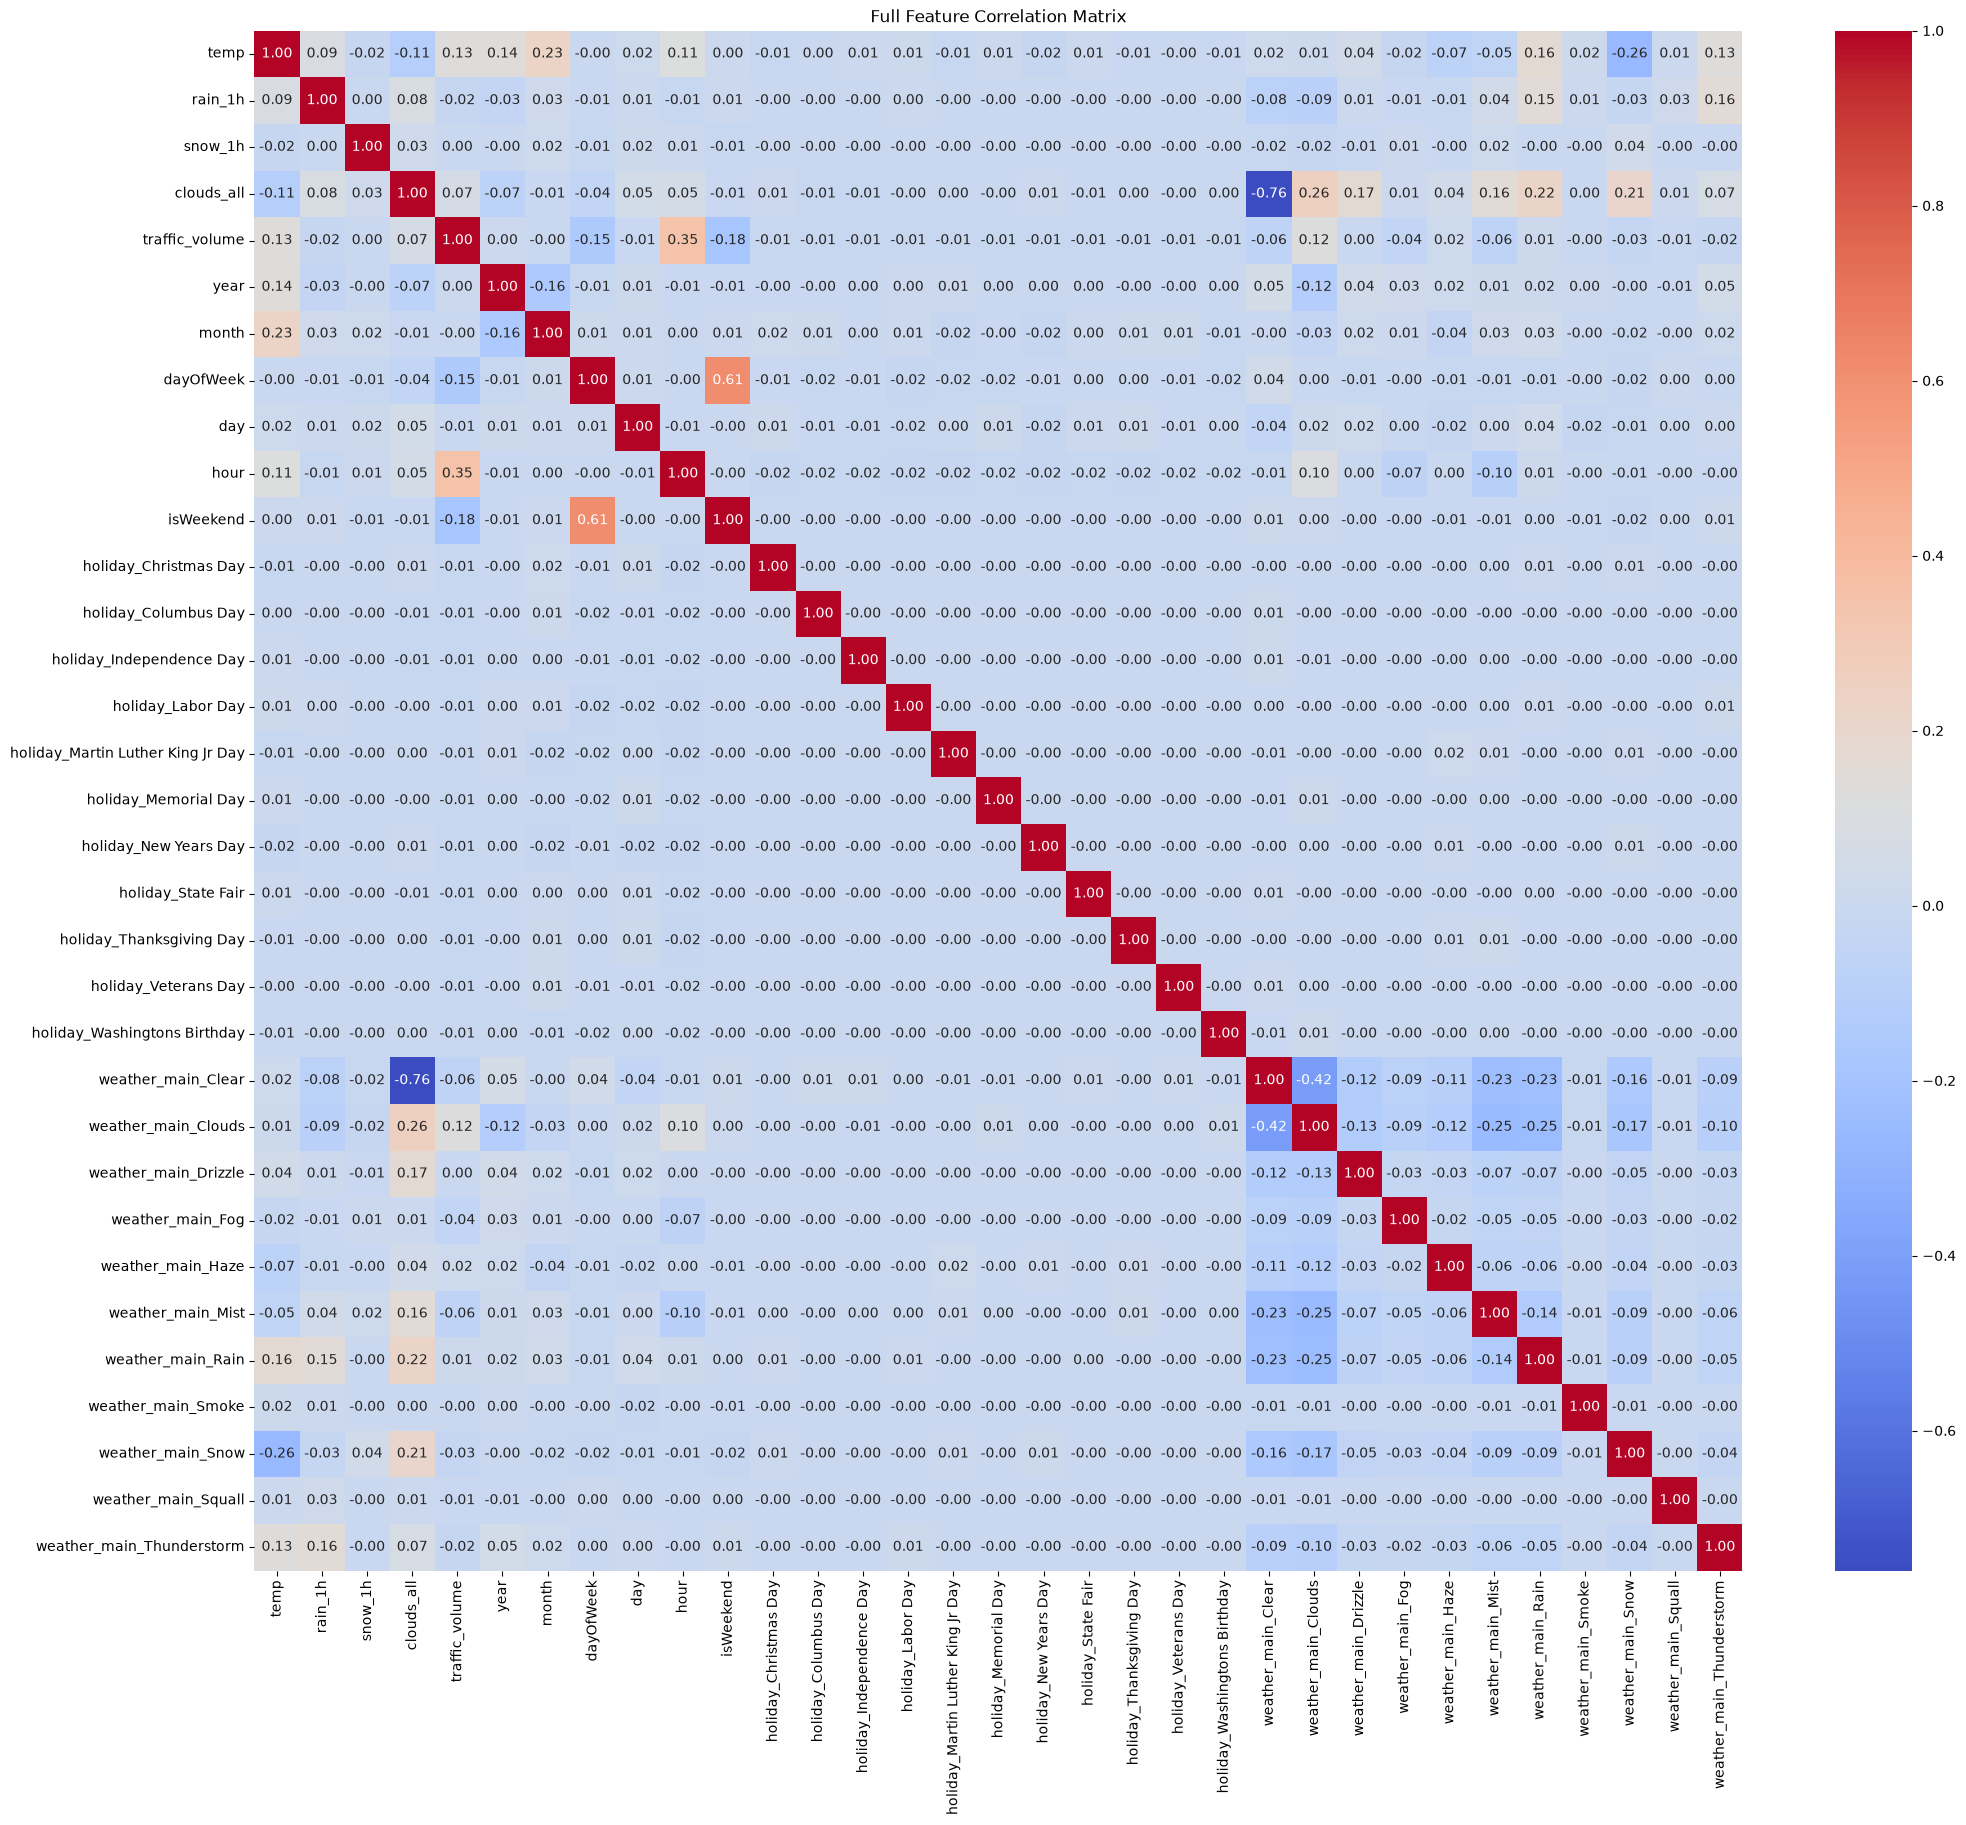

In [25]:
df = df.drop(columns=['date_time', 'weather_description'])
plt.figure(figsize=(24, 20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Full Feature Correlation Matrix")
plt.show()

In [26]:
df = df.drop(columns=['dayOfWeek', 'weather_main_Clear', 'year', 'month', 'day', 'weather_main_Smoke', 'weather_main_Haze', 'weather_main_Squall', 'weather_main_Mist', 'weather_main_Fog', 'weather_main_Drizzle', 'weather_main_Thunderstorm'])
# keep: hour, isWeekend, temp, rain_1h, snow_1h, clouds_all, traffic_volume, holiday_None, weather_main_Clouds, weather_main_Rain, weather_main_Snow, all other holidays

## Construct and standardize train and test sets

In [27]:
# split the data into training and testing sets
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
X_train.columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'isWeekend',
       'holiday_Christmas Day', 'holiday_Columbus Day',
       'holiday_Independence Day', 'holiday_Labor Day',
       'holiday_Martin Luther King Jr Day', 'holiday_Memorial Day',
       'holiday_New Years Day', 'holiday_State Fair',
       'holiday_Thanksgiving Day', 'holiday_Veterans Day',
       'holiday_Washingtons Birthday', 'weather_main_Clouds',
       'weather_main_Rain', 'weather_main_Snow'],
      dtype='str')

## Model Contruction

### Hyperparameter Tuning: SGDRegressor

In [29]:
# split training data into training and validation
X_ptrain, X_valid, y_ptrain, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [31]:
continuous_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour']

binary_cols = ['isWeekend',
       'holiday_Christmas Day', 'holiday_Columbus Day',
       'holiday_Independence Day', 'holiday_Labor Day',
       'holiday_Martin Luther King Jr Day', 'holiday_Memorial Day',
       'holiday_New Years Day', 'holiday_State Fair',
       'holiday_Thanksgiving Day', 'holiday_Veterans Day',
       'holiday_Washingtons Birthday', 'weather_main_Clouds',
       'weather_main_Rain', 'weather_main_Snow']

preprocessor = ColumnTransformer([
    ("continuous", StandardScaler(), continuous_cols),
    ("binary", "passthrough", binary_cols)
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("sgd", SGDRegressor(random_state=42))
])

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [32]:
# Tune penalty and loss first, get a sense of others
param_grid_1 = [
    # L1 and L2, optimal
    {
        "sgd__penalty": ["l1", "l2"],
        "sgd__alpha": [0.0001, 0.001],
        "sgd__learning_rate": ["optimal"],
        "sgd__eta0": [0.01],
        "sgd__max_iter": [1000, 3000],
        "sgd__loss": ["squared_error", "huber"],
    },
    # L1 and L2, non-optimal
    {
        "sgd__penalty": ["l1", "l2"],
        "sgd__alpha": [0.0001, 0.001],
        "sgd__learning_rate": ["constant", "invscaling", "adaptive"],
        "sgd__eta0": [0.01, 0.1],
        "sgd__max_iter": [1000, 3000],
        "sgd__loss": ["squared_error", "huber"],
    },
    # Elasticnet, optimal
    {
        "sgd__penalty": ["elasticnet"],
        "sgd__alpha": [0.0001, 0.001],
        "sgd__l1_ratio": [0.2, 0.5, 0.8],
        "sgd__learning_rate": ["optimal"],
        "sgd__eta0": [0.01],
        "sgd__max_iter": [1000, 3000],
        "sgd__loss": ["squared_error", "huber"],
    },
    # Elasticnet, non-optimal
    {
        "sgd__penalty": ["elasticnet"],
        "sgd__alpha": [0.0001, 0.001],
        "sgd__l1_ratio": [0.2, 0.5, 0.8],
        "sgd__learning_rate": ["constant", "invscaling", "adaptive"],
        "sgd__eta0": [0.01, 0.1],
        "sgd__max_iter": [1000, 3000],
        "sgd__loss": ["squared_error", "huber"],
    },
]

grid_1 = GridSearchCV(
    pipe,
    param_grid=param_grid_1,
    scoring=scoring,
    refit="R2",
    cv=3,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_1.fit(X_train, y_train)

Fitting 3 folds for each of 280 candidates, totalling 840 fits


c:\Users\duckk\OneDrive\Documents\CS 4372\traffic-linear-regression\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'sgd__alpha': [0.0001, 0.001], 'sgd__eta0': [0.01], 'sgd__learning_rate': ['optimal'], 'sgd__loss': ['squared_error', 'huber'], ...}, {'sgd__alpha': [0.0001, 0.001], 'sgd__eta0': [0.01, 0.1], 'sgd__learning_rate': ['constant', 'invscaling', ...], 'sgd__loss': ['squared_error', 'huber'], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'R2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=F

In [33]:
results_1 = pd.DataFrame(grid_1.cv_results_)

results_1.sort_values(
    "mean_test_R2",
    ascending=False
)[[
    "mean_test_R2",
    "std_test_R2",
    "mean_test_MSE",
    "mean_test_MAE",
    "param_sgd__penalty",
    "param_sgd__loss",
    "param_sgd__learning_rate",
    "param_sgd__alpha",
    "param_sgd__l1_ratio",
    "param_sgd__max_iter",
    "param_sgd__eta0"
]].head(7)

,mean_test_R2,std_test_R2,mean_test_MSE,mean_test_MAE,param_sgd__penalty,param_sgd__loss,param_sgd__learning_rate,param_sgd__alpha,param_sgd__l1_ratio,param_sgd__max_iter,param_sgd__eta0
83,0.177019,0.004914,-3.251111e+06,-1588.184765,l2,squared_error,adaptive,0.001,NaN,3000,0.01
107,0.176931,0.005011,-3.251459e+06,-1588.293350,l2,squared_error,adaptive,0.001,NaN,3000,0.10
105,0.176833,0.005071,-3.251844e+06,-1588.324740,l2,squared_error,adaptive,0.001,NaN,1000,0.10
217,0.176756,0.005233,-3.252143e+06,-1588.262340,elasticnet,squared_error,adaptive,0.001,0.2,3000,0.01
81,0.176752,0.004869,-3.252168e+06,-1588.417157,l2,squared_error,adaptive,0.001,NaN,1000,0.01
253,0.176544,0.004997,-3.252981e+06,-1588.633768,elasticnet,squared_error,adaptive,0.001,0.2,3000,0.10
229,0.176449,0.004459,-3.253367e+06,-1588.428132,elasticnet,squared_error,adaptive,0.001,0.5,3000,0.01


In [34]:
results_1.sort_values(
    "mean_test_R2",
    ascending=False
)[[
    "mean_test_R2",
    "std_test_R2",
    "mean_test_MSE",
    "mean_test_MAE",
    "param_sgd__penalty",
    "param_sgd__loss",
    "param_sgd__learning_rate",
    "param_sgd__alpha",
    "param_sgd__l1_ratio",
    "param_sgd__max_iter",
    "param_sgd__eta0"
]].tail(7)

,mean_test_R2,std_test_R2,mean_test_MSE,mean_test_MAE,param_sgd__penalty,param_sgd__loss,param_sgd__learning_rate,param_sgd__alpha,param_sgd__l1_ratio,param_sgd__max_iter,param_sgd__eta0
268,-1.800611e+18,7.381444e+17,-7.108002e+24,-7.732340e+10,elasticnet,squared_error,constant,0.001,0.8,1000,0.1
89,-2.765407e+18,2.290337e+18,-1.086730e+25,-7.467200e+10,l2,squared_error,constant,0.001,NaN,1000,0.1
91,-2.765407e+18,2.290337e+18,-1.086730e+25,-7.467200e+10,l2,squared_error,constant,0.001,NaN,3000,0.1
245,-3.022023e+18,2.077423e+18,-1.188628e+25,-8.776286e+10,elasticnet,squared_error,constant,0.001,0.2,3000,0.1
244,-3.022023e+18,2.077423e+18,-1.188628e+25,-8.776286e+10,elasticnet,squared_error,constant,0.001,0.2,1000,0.1
256,-3.139003e+18,1.772048e+18,-1.235605e+25,-9.185803e+10,elasticnet,squared_error,constant,0.001,0.5,1000,0.1
257,-3.139003e+18,1.772048e+18,-1.235605e+25,-9.185803e+10,elasticnet,squared_error,constant,0.001,0.5,3000,0.1


In [35]:
# Further investigate eta0, alpha, and max_iter
param_grid_2 = {
    "sgd__penalty": ["l2"],
    "sgd__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "sgd__learning_rate": ["adaptive"],
    "sgd__eta0": [0.005, 0.01, 0.05, 0.1, 0.2],
    "sgd__max_iter": [2000, 3000, 4000],
    "sgd__loss": ["squared_error"],
}

grid_2 = GridSearchCV(
    pipe,
    param_grid=param_grid_2,
    scoring=scoring,
    refit="R2",
    cv=3,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_2.fit(X_train, y_train)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


c:\Users\duckk\OneDrive\Documents\CS 4372\traffic-linear-regression\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'sgd__alpha': [0.0001, 0.0005, ...], 'sgd__eta0': [0.005, 0.01, ...], 'sgd__learning_rate': ['adaptive'], 'sgd__loss': ['squared_error'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'R2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here

In [36]:
results_2 = pd.DataFrame(grid_2.cv_results_)

results_2.sort_values(
    "mean_test_R2",
    ascending=False
)[[
    "mean_test_R2",
    "std_test_R2",
    "mean_test_MSE",
    "mean_test_MAE",
    "param_sgd__alpha",
    "param_sgd__eta0",
    "param_sgd__max_iter"
]].head(7)

,mean_test_R2,std_test_R2,mean_test_MSE,mean_test_MAE,param_sgd__alpha,param_sgd__eta0,param_sgd__max_iter
35,0.177027,0.004913,-3.251080e+06,-1588.174055,0.001,0.01,4000
34,0.177019,0.004914,-3.251111e+06,-1588.184765,0.001,0.01,3000
33,0.177007,0.004914,-3.251160e+06,-1588.191111,0.001,0.01,2000
41,0.176938,0.005005,-3.251430e+06,-1588.289812,0.001,0.10,4000
40,0.176931,0.005011,-3.251459e+06,-1588.293350,0.001,0.10,3000
48,0.176908,0.004820,-3.251556e+06,-1589.099550,0.005,0.01,2000
49,0.176907,0.004819,-3.251557e+06,-1589.100557,0.005,0.01,3000


In [37]:
results_2.sort_values(
    "mean_test_R2",
    ascending=False
)[[
    "mean_test_R2",
    "std_test_R2",
    "mean_test_MSE",
    "mean_test_MAE",
    "param_sgd__alpha",
    "param_sgd__eta0",
    "param_sgd__max_iter"
]].tail(7)

,mean_test_R2,std_test_R2,mean_test_MSE,mean_test_MAE,param_sgd__alpha,param_sgd__eta0,param_sgd__max_iter
1,-140961.764825,198169.071460,-5.607273e+11,-260889.242192,0.0001,0.005,3000
0,-144282.545958,195877.343625,-5.737353e+11,-263132.063493,0.0001,0.005,2000
17,-334400.761341,278320.178461,-1.316436e+12,-373617.688763,0.0005,0.005,4000
16,-334400.761414,278320.178373,-1.316436e+12,-373617.767486,0.0005,0.005,3000
15,-334400.761497,278320.178274,-1.316436e+12,-373617.792980,0.0005,0.005,2000
6,-439296.983097,477949.767216,-1.736548e+12,-53219.807034,0.0001,0.050,2000
12,-828920.406659,601956.237323,-3.268847e+12,-84602.936938,0.0001,0.200,2000


In [46]:
# further testing of max_iter and alpha
param_grid_3 = {
    "sgd__penalty": ["l2"],
    "sgd__alpha": [0.001, 0.002, 0.003],
    "sgd__learning_rate": ["adaptive"],
    "sgd__eta0": [0.01],
    "sgd__max_iter": [2000, 2500, 3000, 3500, 4000],
    "sgd__loss": ["squared_error"],
}

grid_3 = GridSearchCV(
    pipe,
    param_grid=param_grid_3,
    scoring=scoring,
    refit="R2",
    cv=3,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_3.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\duckk\OneDrive\Documents\CS 4372\traffic-linear-regression\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'sgd__alpha': [0.001, 0.002, ...], 'sgd__eta0': [0.01], 'sgd__learning_rate': ['adaptive'], 'sgd__loss': ['squared_error'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'R2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versioncha

In [47]:
results_3 = pd.DataFrame(grid_3.cv_results_)

results_3.sort_values(
    "mean_test_R2",
    ascending=False
)[[
    "mean_test_R2",
    "std_test_R2",
    "mean_test_MSE",
    "mean_test_MAE",
    "param_sgd__max_iter",
    "param_sgd__alpha"
]].head(7)

,mean_test_R2,std_test_R2,mean_test_MSE,mean_test_MAE,param_sgd__max_iter,param_sgd__alpha
4,0.177027,0.004913,-3.251080e+06,-1588.174055,4000,0.001
3,0.177023,0.004912,-3.251095e+06,-1588.186254,3500,0.001
2,0.177019,0.004914,-3.251111e+06,-1588.184765,3000,0.001
1,0.177013,0.004913,-3.251137e+06,-1588.188607,2500,0.001
0,0.177007,0.004914,-3.251160e+06,-1588.191111,2000,0.001
9,0.176943,0.004878,-3.251412e+06,-1588.542519,4000,0.002
8,0.176942,0.004877,-3.251418e+06,-1588.546585,3500,0.002


In [48]:
results_3.sort_values(
    "mean_test_R2",
    ascending=False
)[[
    "mean_test_R2",
    "std_test_R2",
    "mean_test_MSE",
    "mean_test_MAE",
    "param_sgd__max_iter",
    "param_sgd__alpha"
]].tail(7)

,mean_test_R2,std_test_R2,mean_test_MSE,mean_test_MAE,param_sgd__max_iter,param_sgd__alpha
6,0.176936,0.004877,-3.251441e+06,-1588.538307,2500,0.002
5,0.176932,0.004878,-3.251457e+06,-1588.534895,2000,0.002
14,0.176917,0.004843,-3.251517e+06,-1588.769357,4000,0.003
13,0.176916,0.004843,-3.251520e+06,-1588.771056,3500,0.003
12,0.176916,0.004843,-3.251523e+06,-1588.771348,3000,0.003
11,0.176915,0.004843,-3.251527e+06,-1588.771655,2500,0.003
10,0.176913,0.004844,-3.251533e+06,-1588.772891,2000,0.003


### Hyperparameter Tuning: OLS

In [49]:
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
l1_wts = [0.0, 0.3, 0.5, 0.7, 1.0]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [50]:
results_ols = []

for alpha in alphas:
    for l1_wt in l1_wts:
        fold_errors = []
        for train_idx, val_idx in kf.split(X_train):
            # split into train and validate
            X_ptrain = X_train.iloc[train_idx]
            X_valid = X_train.iloc[val_idx]
            y_ptrain = y_train.iloc[train_idx]
            y_valid = y_train.iloc[val_idx]

            scaler = StandardScaler()
            X_ptrain[continuous_cols] = scaler.fit_transform(X_ptrain[continuous_cols])
            X_valid[continuous_cols] = scaler.transform(X_valid[continuous_cols])

            X_ptrain = sm.add_constant(
                X_ptrain,
                has_constant="add"
            )
            X_valid = sm.add_constant(
                X_valid,
                has_constant="add"
            )

            model = sm.OLS(y_ptrain, X_ptrain).fit_regularized(alpha=alpha, L1_wt=l1_wt)

            y_pred = model.predict(X_valid)
            mse = mean_squared_error(y_valid, y_pred)
            r2 = r2_score(y_valid, y_pred)
            mae = mean_absolute_error(y_valid, y_pred)
            fold_errors.append([r2, mse, mae])

        results_ols.append({
            "alpha": alpha,
            "L1_wt": l1_wt,
            "cv_r2": np.mean([row[0] for row in fold_errors]),
            "cv_r2_std": np.std([row[0] for row in fold_errors]),
            "cv_mse": np.mean([row[1] for row in fold_errors]),
            "cv_mse_std": np.std([row[1] for row in fold_errors]),
            "cv_mae": np.mean([row[2] for row in fold_errors]),
            "cv_mae_std": np.std([row[2] for row in fold_errors])
        })

In [51]:
results_ols_df = pd.DataFrame(results_ols)

results_ols_df = results_ols_df.sort_values(
    "cv_r2",
    ascending=False
).reset_index(drop=True)

results_ols_df.head(7)

,alpha,L1_wt,cv_r2,cv_r2_std,cv_mse,cv_mse_std,cv_mae,cv_mae_std
0,0.001,1.0,0.177392,0.006314,3.249401e+06,31238.310174,1587.196774,10.911178
1,0.005,1.0,0.177391,0.006312,3.249408e+06,31235.453425,1587.200124,10.907337
2,0.010,1.0,0.177386,0.006309,3.249425e+06,31232.258253,1587.219745,10.899240
3,0.050,1.0,0.177249,0.006240,3.249967e+06,31227.989215,1587.590410,10.869370
4,0.001,0.7,0.177034,0.006182,3.250819e+06,31262.948248,1588.093962,10.831318
5,0.100,1.0,0.177006,0.006158,3.250933e+06,31432.131374,1588.106969,10.915630
6,0.001,0.5,0.176961,0.006156,3.251107e+06,31253.132656,1588.238830,10.818980


In [52]:
results_ols_df.tail(7)

,alpha,L1_wt,cv_r2,cv_r2_std,cv_mse,cv_mse_std,cv_mae,cv_mae_std
23,0.1,0.5,0.163682,0.003310,3.303642e+06,33347.585329,1600.885201,10.600155
24,0.1,0.3,0.154906,0.002689,3.338329e+06,34484.491169,1606.446603,10.695753
25,0.1,0.0,0.139988,0.002218,3.397277e+06,36259.084475,1614.978677,10.886763
26,0.5,0.7,0.111746,0.002486,3.508857e+06,39213.050973,1629.668490,11.298362
27,0.5,0.5,0.047555,0.004227,3.762440e+06,44754.178345,1660.913373,11.961171
28,0.5,0.3,-0.023156,0.005931,4.041761e+06,49658.498509,1696.387529,12.435922
29,0.5,0.0,-0.134481,0.008105,4.481496e+06,55937.422605,1755.843559,13.016576


### Model Fitting: SGDRegressor

In [53]:
# standardize full training and test sets
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the training data AND transform it in one step
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

# Transform the test data using the parameters learned from the training set
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [62]:
# fit SGDRegressor post standardization
sgd_model = SGDRegressor(random_state=42, penalty="l2", alpha=0.01, learning_rate="adaptive",
                         eta0=0.01, max_iter=4000, loss="squared_error")
sgd_model.fit(X_train, y_train)
y_sgdpred = sgd_model.predict(X_test)

In [63]:
r2_score(y_test, y_sgdpred)

0.16764810179501244

In [64]:
mean_squared_error(y_test, y_sgdpred)

3273817.487358748

In [65]:
root_mean_squared_error(y_test, y_sgdpred)

1809.3693617829247

In [67]:
mean_absolute_error(y_test, y_sgdpred)

1594.252397792775

In [68]:
# Target statistics for comparison
print("y mean:", np.mean(y_test))
print("y std:", np.std(y_test))
print("y min:", np.min(y_test))
print("y max:", np.max(y_test))

y mean: 3252.1460732441124
y std: 1983.2330214003664
y min: 1
y max: 7213


### Model Fitting: OLS fit

In [69]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [70]:
ols_nonreg = sm.OLS(y_train, X_train).fit()
ols_nonreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         traffic_volume   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     417.0
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:22:38   Log-Likelihood:            -3.4373e+05
No. Observations:               38554   AIC:                         6.875e+05
Df Residuals:                   38533   BIC:                         6.877e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                              3308.4282     14.357    230.442      0.000    3280.288    3336.568
temp                                200.5070      9.788     20.486      0.000     181.323     219.691
rain_1h                             -46.6152      9.365     -4.978      0.000     -64.971     -28.260
snow_1h                               0.4723      9.194      0.051      0.959     -17.548      18.493
clouds_all                           84.3157     10.653      7.915      0.000      63.436     105.195
hour                                653.5914      9.320     70.124      0.000     635.323     671.860
isWeekend                         -1053.4245     26.236    -40.152      0.000   -1104.848   -1002.001
holiday_Christmas Day             -1245.9590    806.466     -1.545      0.122   -2826.653     334.735
holiday_Columbus Day              -1718.8093    901.542     -1.907      0.057   -3485.854      48.235
holiday_Independence Day          -1233.4928    901.602     -1.368      0.171   -3000.655     533.669
holiday_Labor Day                 -1423.2897    736.210     -1.933      0.053   -2866.281      19.701
holiday_Martin Luther King Jr Day -1489.7627    806.435     -1.847      0.065   -3070.396      90.871
holiday_Memorial Day              -1475.1204    901.579     -1.636      0.102   -3242.237     291.997
holiday_New Years Day              -710.5269    736.295     -0.965      0.335   -2153.684     732.631
holiday_State Fair                -1752.2006    901.583     -1.943      0.052   -3519.327      14.926
holiday_Thanksgiving Day          -1247.8231    901.526     -1.384      0.166   -3014.836     519.190
holiday_Veterans Day              -1632.8614    901.511     -1.811      0.070   -3399.846     134.123
holiday_Washingtons Birthday      -1782.7804   1274.883     -1.398      0.162   -4281.583     716.022
weather_main_Clouds                 324.9484     22.880     14.203      0.000     280.104     369.793
weather_main_Rain                    41.6261     32.355      1.287      0.198     -21.790     105.042
weather_main_Snow                   -17.8588     42.929     -0.416      0.677    -102.001      66.284
==============================================================================
Omnibus:                    17505.145   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2028.798
Skew:                           0.073   Prob(JB):                         0.00
Kurtosis:                       1.886   Cond. No.                         151.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model Fitting: OLS fit_regularized

In [71]:
ols_reg = sm.OLS(y_train, X_train).fit_regularized(alpha=0.001, L1_wt=1.0)
y_olspred = ols_reg.predict(X_test)

In [72]:
r2_score(y_test, y_olspred)

0.16816501416620644

In [73]:
mean_squared_error(y_test, y_olspred)

3271784.3607882475

In [74]:
root_mean_squared_error(y_test, y_olspred)

1808.8074416001964

In [75]:
mean_absolute_error(y_test, y_olspred)

1591.2475071978665